=== Phase 6: FINAL EARLY WARNING SYSTEM ===

Dataset shape: (24300, 38)

=== MODEL PERFORMANCE ===

Vector -> MAE: 9.12 R²: 0.861
Water  -> MAE: 5.06 R²: 0.738

Outbreak AUC: 0.936


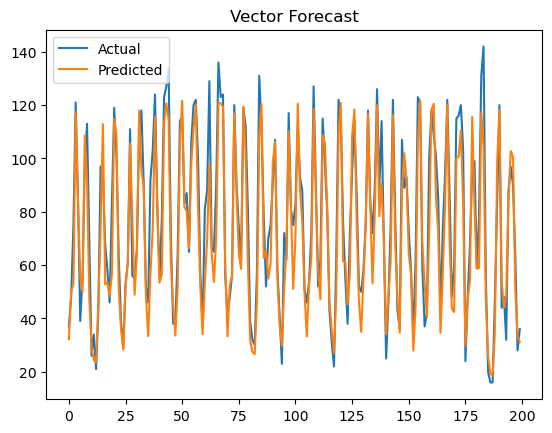


=== EARLY WARNING SYSTEM READY ===


In [23]:
# EARLY WARNING SYSTEM


import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

print("=== Phase 6: FINAL EARLY WARNING SYSTEM ===\n")

DATA_PROCESSED = r"I:\Data Science Projects\disease_prediction\data\processed"

# LOAD
df = pd.read_csv(
    os.path.join(DATA_PROCESSED, "final_modeling_dataset_READY.csv")
)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)

print("Dataset shape:", df.shape)

# FEATURES
df["temp_precip_interaction"] = df["t2m"] * df["tp"]

df["tp_roll3"] = df.groupby("district")["tp"].transform(lambda x: x.rolling(3,1).mean())
df["t2m_roll3"] = df.groupby("district")["t2m"].transform(lambda x: x.rolling(3,1).mean())

df["tp_anomaly_lag1"] = df.groupby("district")["tp_anomaly"].shift(1)
df["t2m_anomaly_lag1"] = df.groupby("district")["t2m_anomaly"].shift(1)

df[["tp_anomaly_lag1","t2m_anomaly_lag1"]] = df.groupby("district")[[
    "tp_anomaly_lag1","t2m_anomaly_lag1"
]].transform(lambda x: x.bfill().ffill())

# TARGETS
df["vector_target"] = df.groupby("district")["vector_borne_cases"].shift(-1)
df["water_target"]  = df.groupby("district")["waterborne_cases"].shift(-1)
df["outbreak_target"] = df.groupby("district")["outbreak"].shift(-1)

df = df.dropna().reset_index(drop=True)

# SPLIT
train = df[df["year"] <= 2021]
test  = df[df["year"] > 2021]

# FEATURES LIST
features = [
    "t2m","tp","t2m_anomaly","tp_anomaly",
    "tp_lag1","tp_lag2","temp_lag1",
    "tp_roll3","t2m_roll3",
    "tp_anomaly_lag1","t2m_anomaly_lag1",
    "temp_precip_interaction",
    "year_trend","sin_month","cos_month",
    "spatial_lag_cases"
]

X_train = train[features]
X_test  = test[features]

# TARGETS
y_train_v = train["vector_target"]
y_test_v  = test["vector_target"]

y_train_w = train["water_target"]
y_test_w  = test["water_target"]

y_train_o = train["outbreak_target"]
y_test_o  = test["outbreak_target"]

# MODELS
rf_v = RandomForestRegressor(n_estimators=500, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_w = RandomForestRegressor(n_estimators=500, max_depth=10, min_samples_leaf=8, random_state=42, n_jobs=-1)

rf_v.fit(X_train, y_train_v)
rf_w.fit(X_train, y_train_w)

pred_v = rf_v.predict(X_test)
pred_w = rf_w.predict(X_test)

print("\n=== MODEL PERFORMANCE ===\n")

print("Vector -> MAE:", round(mean_absolute_error(y_test_v, pred_v),2),
      "R²:", round(r2_score(y_test_v, pred_v),3))

print("Water  -> MAE:", round(mean_absolute_error(y_test_w, pred_w),2),
      "R²:", round(r2_score(y_test_w, pred_w),3))

# OUTBREAK CLASSIFIER
clf = RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train_o)

prob_outbreak = clf.predict_proba(X_test)[:,1]

# AUC
if len(np.unique(y_test_o)) < 2:
    print("\n Only one class in test set — AUC undefined")
else:
    auc = roc_auc_score(y_test_o, prob_outbreak)
    print("\nOutbreak AUC:", round(auc,3))

# VISUALIZATION
plt.figure()
plt.plot(y_test_v.values[:200], label="Actual")
plt.plot(pred_v[:200], label="Predicted")
plt.title("Vector Forecast")
plt.legend()
plt.show()

print("\n=== EARLY WARNING SYSTEM READY ===")

In [24]:
import joblib
import os

DATA_PROCESSED = r"I:\Data Science Projects\disease_prediction\data\processed"

# Save models
joblib.dump(rf_v, os.path.join(DATA_PROCESSED, "model_vector_borne.pkl"))
joblib.dump(rf_w, os.path.join(DATA_PROCESSED, "model_waterborne.pkl"))
joblib.dump(clf, os.path.join(DATA_PROCESSED, "model_outbreak_clf.pkl"))

print("Models saved successfully!")

Models saved successfully!
